In [1]:
from pathlib import Path
import sqlite3

BASE_DIR = Path.cwd().parent
DB_PATH = BASE_DIR / "inventorydb.db"
conn = sqlite3.connect(DB_PATH)

### Loading the data

In [2]:
import pandas as pd

purchase_agg_df = pd.read_sql_query("""
SELECT p.PONumber,
COUNT (DISTINCT p.Brand) as total_brands,
SUM (p.Quantity) as total_item_quantity,
SUM (p.Dollars) as total_item_dollars,
AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
FROM purchases p 
GROUP BY p.PONumber
""", conn)

purchase_agg_df

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,10000,1,99,758.34,7.0
1,10003,1,96,2960.64,8.0
2,10005,1,20,894.60,10.0
3,10007,1,57,242.25,10.0
4,10010,1,31,1799.24,9.0
...,...,...,...,...,...
38308,99987,1,21,123.27,4.0
38309,99991,1,47,1813.26,8.0
38310,99994,1,41,174.25,5.0
38311,99995,1,42,1663.20,9.0


In [3]:
pd.read_sql_query("""
SELECT 
vi.quantity as invoice_quantity, 
vi.dollars as invoice_dollars, 
vi.freight,
(julianday(vi.invoicedate) - julianday(vi.podate)) AS days_po_to_invoice,
(julianday(vi.paydate) - julianday(vi.invoicedate)) AS days_to_pay
FROM vendor_invoice vi 
""", conn)

,invoice_quantity,invoice_dollars,freight,days_po_to_invoice,days_to_pay
0,22,141.46,60.75,7.0,22.0
1,100,6823.00,100.22,11.0,22.0
2,86,552.98,98.41,10.0,25.0
3,91,6208.93,70.59,13.0,26.0
4,59,3388.96,77.01,11.0,18.0
...,...,...,...,...,...
49841,45,239.40,72.65,8.0,20.0
49842,93,3552.60,126.48,5.0,14.0
49843,55,810.15,83.43,12.0,21.0
49844,81,6271.83,88.52,8.0,23.0


In [4]:
df = pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.brand) AS total_brands,
        SUM(P.Quantity) AS total_item_quantity,
        SUM(P.Dollars) AS total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)
SELECT
    vi.ponumber,
    vi.quantity AS invoice_quantity,
    vi.dollars AS invoice_dollars,
    vi.freight,
    (julianday(vi.invoicedate) - julianday(vi.podate)) AS days_po_to_invoice,
    (julianday(vi.paydate) - julianday(vi.invoicedate)) AS days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay
FROM vendor_invoice vi
LEFT JOIN purchase_agg pa ON vi.ponumber = pa.ponumber
""", conn)

print("Data loaded:", df.shape)
df.head()

Data loaded: (49846, 10)


,ponumber,invoice_quantity,invoice_dollars,freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,11084,22,141.46,60.75,7.0,22.0,2,62,706.66,5.000000
1,11353,100,6823.00,100.22,11.0,22.0,3,256,15606.88,8.333333
2,11531,86,552.98,98.41,10.0,25.0,1,86,552.98,8.000000
3,11580,91,6208.93,70.59,13.0,26.0,1,91,6208.93,9.000000
4,11926,59,3388.96,77.01,11.0,18.0,1,59,3388.96,8.000000


### Feature Engineering

In [5]:
import numpy as np

# Avoiding zero divides
df['total_item_dollars'] = df['total_item_dollars'].replace(0, 1)
df['total_item_quantity'] = df['total_item_quantity'].replace(0, 1)

# Invoice vs item-level total
df['invoice_ratio'] = df['invoice_dollars'] / df['total_item_dollars']
# Cost efficiency
df['freight_per_unit'] = df['freight'] / df['invoice_quantity']
df['freight_ratio'] = df['freight'] / df['invoice_dollars']
# Complexity indicator
df['quantity_per_brand'] = df['invoice_quantity'] / df['total_brands'] 

df['days_po_to_invoice'] = df['days_po_to_invoice'].fillna(df['days_po_to_invoice'].median())
df['days_to_pay'] = df['days_to_pay'].fillna(df['days_to_pay'].median())

# Relative order size. Abnormal order size
df['relative_order_size'] = df['invoice_quantity'] / df['total_item_quantity']

# Log transforms to reduce skew
df['log_invoice_dollars'] = np.log1p(df['invoice_dollars'])
df['log_invoice_quantity'] = np.log1p(df['invoice_quantity'])
df['log_freight'] = np.log1p(df['freight'])

### Training a supervised model (Random Forest)

#### Supervised Labeling

In [6]:
def create_invoice_risk_label(row):
    # Invoice total mismatch with item-level total (>10% difference)
    if abs(row["invoice_dollars"] - row["total_item_dollars"]) / row["total_item_dollars"] > 0.1:
        return 1
    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1
    return 0

df['flag_invoice'] = df.apply(create_invoice_risk_label, axis=1)
print(df['flag_invoice'].value_counts())

flag_invoice
0    30126
1    19720
Name: count, dtype: int64


<Axes: xlabel='flag_invoice'>

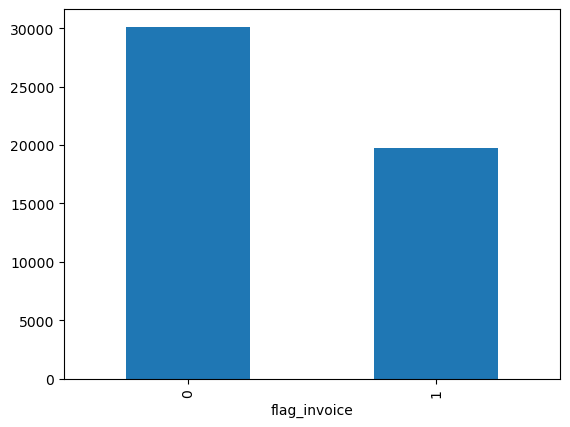

In [7]:
df["flag_invoice"].value_counts().plot(kind="bar")

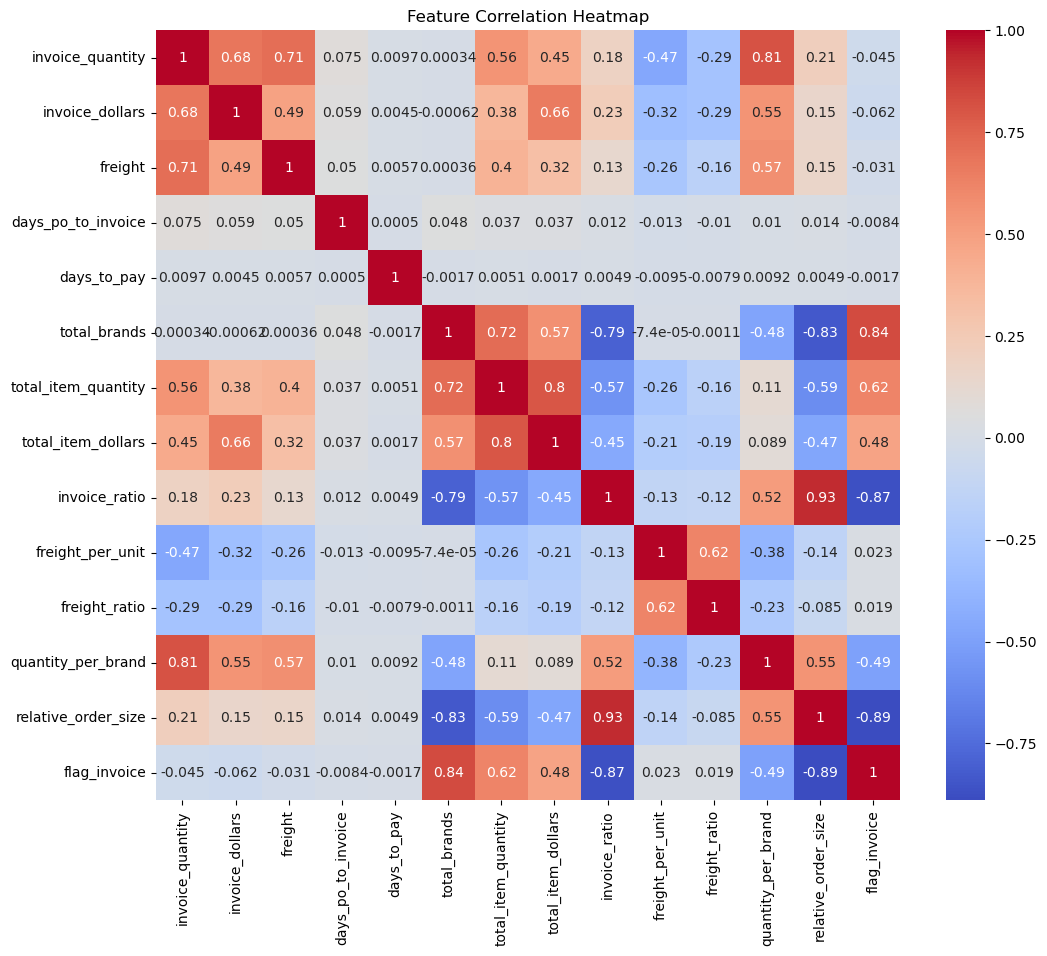

In [9]:
# Heatmap of correlations among engineered features
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df[['invoice_quantity','invoice_dollars','freight','days_po_to_invoice','days_to_pay', 'total_brands','total_item_quantity','total_item_dollars', 'invoice_ratio','freight_per_unit','freight_ratio','quantity_per_brand','relative_order_size', 'flag_invoice']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [10]:
flagged = df[df['flag_invoice'] == 1]
normal = df[df['flag_invoice'] == 0]

from scipy.stats import ttest_ind

significant_features = []
non_significant_features = []
results = []

metrics = ['invoice_quantity', 'invoice_dollars', 'freight', 'days_po_to_invoice', 'days_to_pay', 'total_brands', 'total_item_quantity', 'total_item_dollars', 'freight_per_unit', 'quantity_per_brand', 'relative_order_size', 'log_invoice_dollars', 'log_invoice_quantity', 'log_freight']

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var = False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            "metric": metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3),   
        })
    else:
        non_significant_features.append(metric)

In [11]:
non_significant_features

['days_to_pay']

In [12]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'freight',
 'days_po_to_invoice',
 'total_brands',
 'total_item_quantity',
 'total_item_dollars',
 'freight_per_unit',
 'quantity_per_brand',
 'relative_order_size',
 'log_invoice_dollars',
 'log_invoice_quantity',
 'log_freight']

In [13]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(49.07),
  'normal_mean': np.float64(51.76),
  'p_value': np.float64(0.0)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(1962.51),
  'normal_mean': np.float64(2185.95),
  'p_value': np.float64(0.0)},
 {'metric': 'freight',
  'flagged_mean': np.float64(82.54),
  'normal_mean': np.float64(84.34),
  'p_value': np.float64(0.0)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(8.78),
  'normal_mean': np.float64(8.92),
  'p_value': np.float64(0.045)},
 {'metric': 'total_brands',
  'flagged_mean': np.float64(2.31),
  'normal_mean': np.float64(1.05),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(117.73),
  'normal_mean': np.float64(52.57),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(4833.39),
  'normal_mean': np.float64(2196.01),
  'p_value': np.float64(0.0)},
 {'metric': 'freight_per_unit',
  'flagged_mean'

In [14]:
features = ['invoice_quantity', 'invoice_dollars', 'freight', 'days_po_to_invoice', 'total_brands', 'total_item_quantity', 'total_item_dollars', 'freight_per_unit', 'quantity_per_brand', 'relative_order_size', 'log_invoice_dollars', 'log_invoice_quantity', 'log_freight']

X = df[features]
y = df['flag_invoice']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=6, class_weight='balanced')
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=6, n_estimators=200,
                       random_state=42)

In [18]:
from sklearn.metrics import classification_report

y_pred = rf.predict(X_test_scaled)
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      6026
           1       0.96      1.00      0.98      3944

    accuracy                           0.99      9970
   macro avg       0.98      0.99      0.98      9970
weighted avg       0.99      0.99      0.99      9970



#### Feature importance

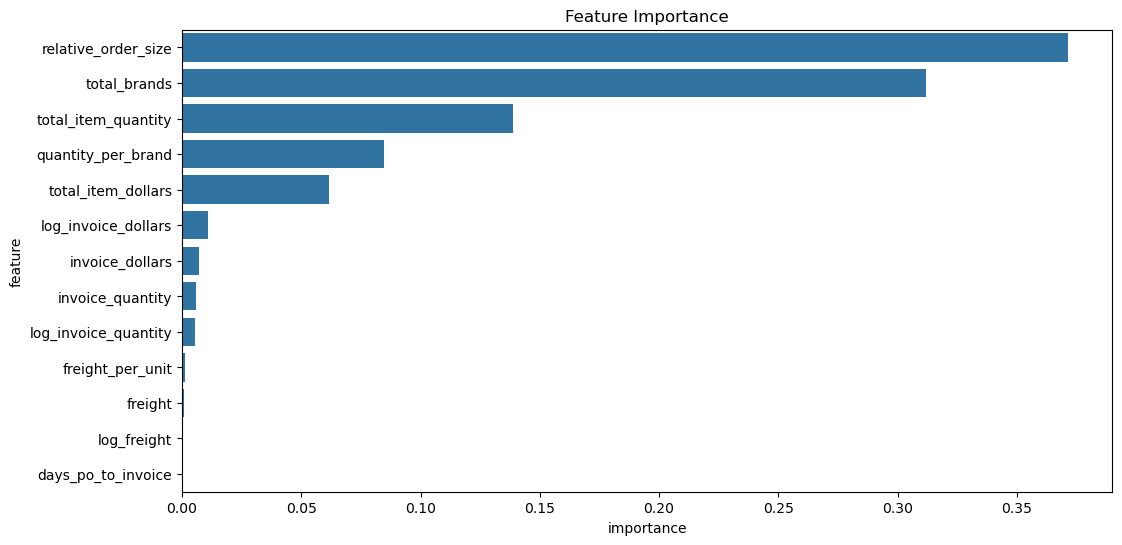

In [19]:
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title("Feature Importance")
plt.show()

In [20]:
feature_importance

,feature,importance
9,relative_order_size,0.371352
4,total_brands,0.311817
5,total_item_quantity,0.138659
8,quantity_per_brand,0.084516
6,total_item_dollars,0.061627
10,log_invoice_dollars,0.010690
1,invoice_dollars,0.006982
0,invoice_quantity,0.005728
11,log_invoice_quantity,0.005621
7,freight_per_unit,0.001214


In [21]:
features = ['total_brands', 'total_item_quantity', 'total_item_dollars', 'quantity_per_brand', 'relative_order_size', 'log_invoice_dollars']

X = df[features]
y = df['flag_invoice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
joblib.dump(scaler, MODEL_PATH / 'anomaly_scaler.pkl')

['C:\\Users\\Administrator\\Desktop\\Invoice-Intelligence\\artifacts\\anomaly_scaler.pkl']

In [22]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ['gini', 'entropy']  
}

scorer = make_scorer(f1_score)

grid_search = GridSearchCV(
    estimator = rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1    
)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 4, 5, 6],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 3, 5],
                         'n_estimators': [100, 200, 300]},
             scoring=make_scorer(f1_score, response_method='predict'),
             verbose=2)

In [23]:
grid_search.best_params_

{'criterion': 'entropy',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [25]:
from sklearn.metrics import classification_report

y_pred = grid_search.predict(X_test_scaled)
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      6026
           1       0.98      0.99      0.99      3944

    accuracy                           0.99      9970
   macro avg       0.99      0.99      0.99      9970
weighted avg       0.99      0.99      0.99      9970



In [37]:
MODEL_PATH = BASE_DIR / "artifacts"
MODEL_PATH.mkdir(exist_ok=True)

import joblib
joblib.dump(grid_search, MODEL_PATH / 'anomaly_detector.pkl')

['C:\\Users\\Administrator\\Desktop\\Invoice-Intelligence\\artifacts\\anomaly_detector.pkl']

### Unsupervised Anomaly Detection (Isolation Forest)

In [27]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso.fit(X_train_scaled)

IsolationForest(contamination=0.05, n_estimators=200, random_state=42)

In [28]:
joblib.dump(iso, MODEL_PATH / 'iso_forest.pkl')

['C:\\Users\\Administrator\\Desktop\\Invoice-Intelligence\\artifacts\\iso_forest.pkl']

In [29]:
# -1 is anomaly, 1 is normal
df['iso_label'] = iso.predict(scaler.transform(X))
df['iso_score'] = iso.decision_function(scaler.transform(X))  # Higher = more normal

# Convert to probability-like score: lower - more suspicious
df['anomaly_score'] = -df['iso_score']

### Combining Supervised & Unsupervised Scores

In [31]:
# Normalizing scores to 0-1
from sklearn.preprocessing import MinMaxScaler
score_scaler = MinMaxScaler()

df['rf_score'] = grid_search.predict_proba(X)[:,1]  # probability of being flagged
df[['rf_score', 'anomaly_score']] = score_scaler.fit_transform(df[['rf_score','anomaly_score']])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [32]:
# Combined risk score (weighted)
df['risk_score'] = 0.6*df['rf_score'] + 0.4*df['anomaly_score']

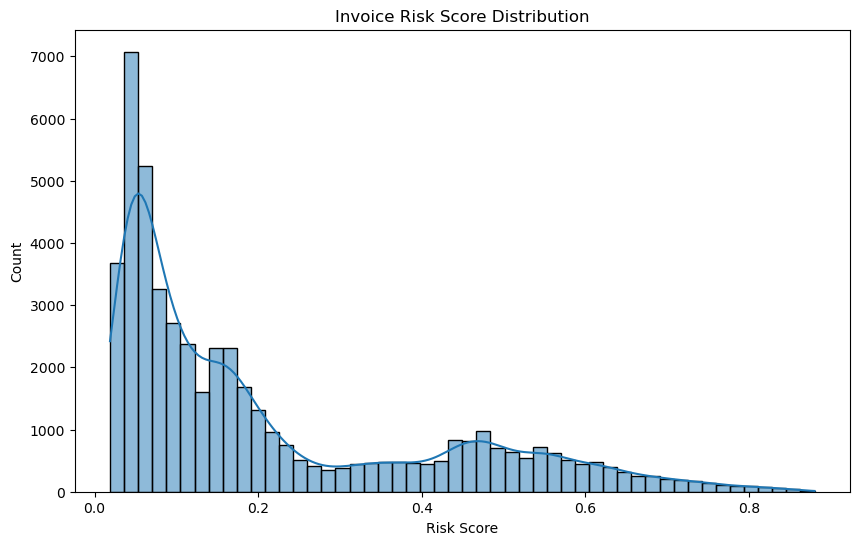

In [33]:
plt.figure(figsize=(10,6))
sns.histplot(df['risk_score'], bins=50, kde=True)
plt.title("Invoice Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Count")
plt.show()

In [34]:
# Rank invoices by risk
suspicious_invoices = df.sort_values('risk_score', ascending=False)
suspicious_invoices[['ponumber','invoice_quantity','invoice_dollars','freight','risk_score']].head(20)

,ponumber,invoice_quantity,invoice_dollars,freight,risk_score
46069,75931,1,4.24,56.63,0.879966
31295,14792,1,5.59,31.53,0.876519
12697,56534,1,5.87,67.46,0.876207
18609,58174,1,11.12,34.71,0.868835
41200,50806,1,5.85,54.75,0.866726
8456,24438,1,18.69,65.00,0.864749
22993,15760,3,95.61,56.92,0.863958
37827,30466,1,10.68,60.21,0.863739
43746,78232,1,10.80,55.20,0.862275
27125,49268,1,11.13,73.66,0.862231


In [35]:
# Saving Suspicious Invoices
suspicious_invoices[['ponumber','invoice_quantity','invoice_dollars','freight','risk_score']].to_csv(MODEL_PATH / 'suspicious_invoices.csv', index=False)